
`Paula Andrea Cano- Pamela Huacca Arce`

### **1. Etapas de registro y componentes de equipo de adquisición**

In [ ]:
import IPython

# Esquema
diagrama = """
graph LR
    A((Célula)) -->|Potencial de Acción| B[Tejidos/Cuerpo]
    B -->|Corriente Iónica| C[Interfaz Piel-Electrodo]
    C -->|Corriente Eléctrica| D[Acondicionamiento]
    D -->|Amplificación/Filtrado| E[Arduino ADC]
    E -->|Bits/Discretización| F[Software PC]
"""
def display_mermaid(graph):
    import base64
    # Cambiamos .encode("ascii") por .encode("utf-8")
    graphbytes = graph.encode("utf-8")
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    display(IPython.display.Image(url="https://mermaid.ink/img/" + base64_string))

display_mermaid(diagrama)

1. **Generación del Biopotencial (Célula):** La señal se origina por la actividad electroquímica en las membranas de las células excitables (miocitos en ECG y fibras musculares en EMG). Este proceso implica el movimiento de iones (Na+, K+, Cl-) a través de la membrana celular, generando un potencial de acción que se propaga por el tejido. [1]

2. **Conducción (Cuerpo):** El cuerpo actúa como un medio conductor que permite que los potenciales generados internamente se proyecten hacia la superficie de la piel.

3. **Interfaz Piel-Electrodo (Transducción):** Es el componente encargado de convertir la corriente iónica del cuerpo en corriente electrónica para el equipo. Es la etapa más crítica debido a la impedancia de la piel y la necesidad de geles electrolíticos para asegurar la fidelidad de la señal.[1]

4. **Acondicionamiento Analógico (Shield Olimex):**

* Amplificador de Instrumentación: Dado que las señales biológicas tienen  amplitudes muy bajas (mV o μV), se requiere una alta ganancia y una alta impedancia de entrada para no cargar la fuente.[1]
*   Filtrado: Se eliminan ruidos de baja frecuencia (movimiento) y alta frecuencia (interferencias electromagnéticas) mediante filtros pasa-banda.

5. **Digitalización y Adquisición (Arduino UNO):**

* ADC (Conversor Analógico-Digital): Realiza la discretización de la señal analógica, transformándola en datos digitales mediante procesos de muestreo y cuantización.
* Procesamiento y Registro: La señal final se envía al computador para su visualización y análisis (como la detección de picos R en el ECG).







**Componentes del equipo de adquisición**

1. **Electrodos (Transductores):** Interfaz que convierte las corrientes iónicas del cuerpo en corrientes electrónicas para el circuito[1]

2. **Amplificador de Instrumentación:** Componente del Shield Olimex que aumenta la amplitud de las bioseñales (mV/μV) y posee alta impedancia de entrada para evitar distorsiones[1]

3. **Filtros:** Circuitos que eliminan ruidos antes de la digitalización.

4. **Conversor Analógico-Digital (ADC):** Módulo del Arduino UNO encargado de la discretización (muestreo y cuantización) de la señal analógica en datos digitales.

5. **Unidad de Procesamiento/Visualización:** El microcontrolador gestiona los datos y el computador permite el registro y análisis final (como la detección de picos R o contracciones).



### **2. Tabla con las principales fuentes de ruido en el registro de biopotenciales.**

| Fuente de Ruido | ¿Estática o Variante? | Descripción | Estrategia de Solución |
| :--- | :---: | :--- | :--- |
|**Ruido del equipo electrónico de adquisición**| Estática/Variante| Ruido inherente a los componentes electrónicos utilizados en el sistema de registro.| Utilizar componentes de alta precisión y amplificadores de instrumentación de bajo ruido (como el Shield Olimex).|
|**Ruido por contacto entre piel y electrodo**| Variante| Interferencia que ocurre en la interfaz donde se capta la señal biológica por imperfecciones o inestabilidad en el contacto físico.|Limpieza abrasiva de la zona, uso de gel electrolítico y fijación mecánica firme para evitar cualquier movimiento.|
|**Interferencia de frecuencia de potencia (60 Hz)**| Variante| Se refiere a la interferencia de la línea eléctrica y sus armónicos.Incluye el acoplo capacitivo con el paciente y el equipo. | Solución: Uso de cables blindados, electrodo de referencia (RL), y aplicación de filtros rechaza-banda (Notch) sintonizados a 60 Hz. |
|**Interferencias Inductivas**| Variante| Campos magnéticos variables generados por la red eléctrica que inducen voltajes de ruido en los lazos de los cables.| Trenzar los cables de los electrodos y alejarse de fuentes de campos magnéticos como transformadores.|
|**Potencial de Media Celda (Polarización)**| Variante|Distribución de cargas en la interfaz electrodo-electrolito que genera un potencial galvánico propenso a fluctuaciones. | Utilizar electrodos de materiales con bajas polarizaciones como el Plata-Cloruro de Plata (Ag/AgCl).|
|**Movimiento del Electrodo(Artefactos)**|Variante|Variación transitoria del potencial de media celda debido al desplazamiento mecánico, produciendo fluctuaciones < 1Hz. |Asegurar una fijación mecánica estable de los electrodos a la superficie cutánea mediante adhesivos.|
| **Potenciales Bioeléctricos (EMG/ECG)** |Variante| Interferencia de otros biopotenciales presentes en el cuerpo (ej. actividad muscular EMG durante un registro de ECG). | Es importante que el paciente esté relajado y en reposo absoluto para que su actividad muscular sea mínima.|
| **Sistemas Fisiológicos (Respiración)** | Variante| Provoca el balanceo de la línea base y cambios de amplitud debido al movimiento del tórax y cambio de posición del corazón. |Ubicación adecuada de los electrodos y uso de filtros pasa-altos para estabilizar la línea base de la señal. |

Tabla1 [2]


La mayoría de las fuentes se consideran variantes en el tiempo debido a la naturaleza dinámica de la interfaz piel-electrodo y a los artefactos biológicos (respiración, movimiento) que impiden un nivel de ruido constante. El ruido del equipo es el único que presenta una componente estática representativa debido a las características térmicas de sus componentes internos.

### **3. Problemática del acoplamiento piel-electrodo y estrategias de mejora**

La principal dificultad radica en que esta interfaz es una de las tres fuentes primarias de ruido en el registro de biopotenciales. De acuerdo con la literatura [2], se identifican los siguientes puntos críticos:

- **Generación de ruido por contacto:** El contacto físico directo entre la piel y el electrodo introduce interferencias mecánicas y químicas que degradan la señal de origen.

- **Variabilidad de la impedancia:** La impedancia de entrada del sistema se ve afectada por los diferentes tipos de piel de los usuarios (grosor, hidratación, vello) y las características del electrodo, lo que exige una optimización constante de los amplificadores frontales (AFE).

- **Barreras de logística y recursos:** En la práctica clínica y de laboratorio, la preparación de la piel (limpieza abrasiva, aplicación de gel, colocación precisa) consume tiempo y recursos considerables, limitando la eficiencia de la tecnología.

- **Diseño deficiente de la interfaz:** A menudo se prioriza la sofisticación electrónica del equipo sobre la ergonomía y comodidad de la interfaz sensor-paciente, lo que genera artefactos por incomodidad o movimiento.

Se implementan diversas innovaciones tecnológicas y metodológicas para mejorar el acomplameiento piel- electrodo, tales como el uso de amplificadores de alta impedancia con front-ends optimizados para adaptarse a la resistencia de la capa córnea, el empleo de electrodos activos que integran la pre-amplificación para reducir el ruido de baja frecuencia e interferencias en los cables, y el desarrollo de diseños para mediciones capacitivas que permiten registros sin contacto galvánico directo. Asimismo, resulta fundamental la implementación de amplificadores diferenciales con un alto rechazo de modo común (CMRR) para eliminar interferencias externas como la de la línea eléctrica, junto con la creación de sistemas que permiten registros fiables sin necesidad de preparación abrasiva previa de la piel, optimizando así la experiencia del paciente[2]

Se considera la etapa más crítica en el registro de biopotenciales de superficie (sEMG, EEG, ECG) debido a que es el primer punto de captación y transducción de la señal, donde cualquier degradación resulta irreversible para las etapas posteriores. Dado que los biopotenciales poseen amplitudes extremadamente bajas del orden de los milivoltios (mV) o microvoltios ($\mu$V) y operan en rangos de frecuencia muy bajos, son altamente vulnerables al ruido ambiental y de contacto que se solapa en su mismo espectro. Si la señal se contamina en esta interfaz inicial por un mal contacto o una impedancia inestable, el procesamiento digital y la extracción de características clínicas, como la fuerza o la fatiga neuromuscular, pierden total validez. En consecuencia, la fidelidad de este acoplamiento es lo que determina si la actividad fisiológica será registrada con precisión o si será enmascarada por artefactos de movimiento, invalidando cualquier diagnóstico o análisis posterior[2]



### **4. Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

In [21]:
!pip install neurokit2 py-ecg-detectors

Señal cargada. Longitud total: 1000 muestras (1 segundo).


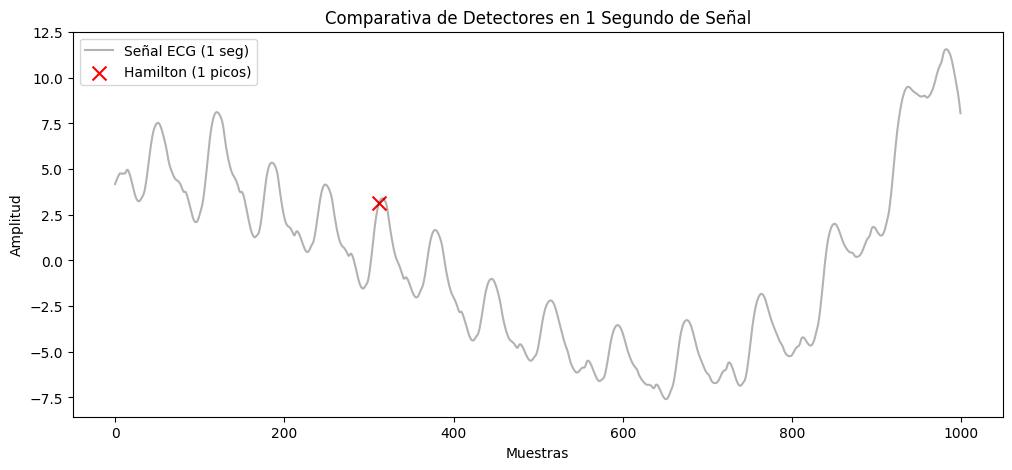

Picos con NeuroKit: 0
Picos con Hamilton: 1


In [46]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt

# CARGA DE DATOS
df = pd.read_csv('ECG_Paula.csv', header=None)
ecg_raw = df[0].values
fs = 1000
print(f"Señal cargada. Longitud total: {len(ecg_raw)} muestras (1 segundo).")

# PROCESAMIENTO (Inversión y Limpieza)
ecg_inv = (ecg_raw - np.mean(ecg_raw)) * -1
# Aquí ocurre el filtrado (Butterworth y eliminación de ruido de 60Hz)
ecg_clean = nk.ecg_clean(ecg_inv, sampling_rate=fs, method="neurokit")

# DETECCIÓN DE PICOS
# Algoritmo -NeuroKit
peaks_nk = nk.ecg_findpeaks(ecg_clean, sampling_rate=fs, method="neurokit")["ECG_R_Peaks"]

# Algoritmo - Hamilton (Sustituto de la librería Detectors)
peaks_ham = nk.ecg_findpeaks(ecg_clean, sampling_rate=fs, method="hamilton")["ECG_R_Peaks"]

# GRÁFICA
plt.figure(figsize=(12, 5))
plt.plot(ecg_clean, color='black', alpha=0.3, label='Señal ECG (1 seg)')

# Graficamos NeuroKit
if len(peaks_nk) > 0:
    plt.scatter(peaks_nk, ecg_clean[peaks_nk], color='blue', label=f'NeuroKit ({len(peaks_nk)} picos)', s=80)

# Graficamos Hamilton
if len(peaks_ham) > 0:
    plt.scatter(peaks_ham, ecg_clean[peaks_ham], color='red', marker='x', label=f'Hamilton ({len(peaks_ham)} picos)', s=100)

plt.title("Comparativa de Detectores en 1 Segundo de Señal")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

print(f"Picos con NeuroKit: {len(peaks_nk)}")
print(f"Picos con Hamilton: {len(peaks_ham)}")

Para la detección de los picos R, no se utilizó la librería original py-ecg-detectors debido a problemas de instalación en el entorno de desarrollo, optando en su lugar por la librería NeuroKit2 para ejecutar tanto su método nativo como el algoritmo sustituto de Hamilton. Al examinar los datos crudos del Arduino, notamos que el registro estaba invertido (con los picos hacia abajo, y al ejecutarlo nos daba cero picos), por lo que fue necesario aplicar una inversión matemática en el código y posteriormente utilizar los filtros internos de limpieza de NeuroKit para eliminar el ruido eléctrico y estabilizar la línea base. Tras procesar la señal de un segundo, el algoritmo de Hamilton detectó 1 pico mientras que NeuroKit detectó 0. esta diferencia puede darse en que Hamilton utiliza umbrales de amplitud más permisivos que lograron identificar el latido a pesar de la baja relación señal-ruido, mientras que el filtro de calidad de NeuroKit es mucho más estricto y prefirió descartar el evento al no cumplir con una morfología clínica perfecta. Por lo tanto, para las condiciones de esta señal corta y con interferencias de hardware, el algoritmo de Hamilton demostró un mejor desempeño inicial, aunque para un análisis de variabilidad cardíaca (HRV) a largo plazo, la rigurosidad y capacidad de filtrado de NeuroKit lo convertirían en la opción más confiable.

In [48]:
#  CÁLCULO DE HRV ---

print(" Cálculo de HRV ---")

if len(peaks_ham) > 1:
    try:
        hrv_indices = nk.hrv(peaks_ham, sampling_rate=fs, show=True)
        print("Cálculo de HRV exitoso:")
        display(hrv_indices)
    except Exception as e:
        print(f"No hay suficientes datos para un análisis estadístico completo: {e}")
else:
    print(f" Se detectaron {len(peaks_ham)} picos.")
    print("La Variabilidad de la Frecuencia Cardíaca (HRV) mide la variación de tiempo entre intervalos R-R sucesivos.")
    print("Para calcular al menos un intervalo R-R, se requieren un mínimo de 2 picos R.")


 Cálculo de HRV ---
 Se detectaron 1 picos.
La Variabilidad de la Frecuencia Cardíaca (HRV) mide la variación de tiempo entre intervalos R-R sucesivos.
Para calcular al menos un intervalo R-R, se requieren un mínimo de 2 picos R.


No fue posible calcular la HRV porque el script de adquisición (Lectura_Serial.py) tenía configurado el límite numero_datos = 1000, truncando la grabación a solo 1000 muestras y omitiendo el resto del minuto estipulado. Dado que la HRV mide el tiempo entre latidos (intervalos R-R), matemáticamente se necesitan al menos 2 picos R para obtener un dato. Al haberse registrado únicamente un latido en esa breve ventana de datos, el cálculo nos resultó  inviable.

In [ ]:
# EXTRACCIÓN DE CARACTERÍSTICAS HRV
from hrvanalysis import get_time_domain_features
import numpy as np

print("\n--- Análisis HRV: hrvanalysis ---")

rr_intervals_ms = (np.diff(peaks_ham) / fs) * 1000

if len(rr_intervals_ms) > 1:
    try:
        time_domain_features = get_time_domain_features(rr_intervals_ms)
        print("Características extraídas exitosamente:")
        for metrica, valor in time_domain_features.items():
            print(f"- {metrica}: {valor}")
    except Exception as e:
        print(f"Error al calcular: {e}")
else:
    print(f"Intervalos R-R disponibles: {len(rr_intervals_ms)}.")
    print("No se puede ejecutar 'get_time_domain_features'.")
    print("Motivo: El archivo carece de los intervalos necesarios debido a la limitación de 1000 muestras en la captura.")

La función get_time_domain_features requiere múltiples intervalos R-R para calcular métricas estadísticas. Como nuestro script Lectura_Serial.py limitó la captura a 1000 muestras (1 segundo), solo se registró un latido. Esto imposibilita medir el tiempo entre latidos consecutivos, por lo que la extracción de características es matemáticamente inviable por falta de datos, aunque el código se haya implementado correctamente.

### **5 Aplicaciones clínicas del uso de ECG y EMG**

**ECG**
- Aplicación 1: **Detección de susceptibilidad a Fibrilación Auricular Paroxística (PAF)** [3]

Se busca identificar pacientes con riesgo de sufrir fibrilación auricular incluso cuando su ritmo cardíaco es aparentemente normal (sinusal), eliminando la necesidad de esperar a un episodio activo de arritmia para el diagnóstico. A diferencia de los métodos tradicionales que requieren monitorear un episodio de 30 segundos, esta técnica detecta cambios sutiles y no evidentes al ojo humano en la morfología de la onda del ECG, permitiendo un diagnóstico rápido en atención primaria con un registro estándar.

 *Tipo de registro utilizado* consiste en un ECG estándar de 12 derivaciones de corta duración (10 segundos), con señales muestreadas originalmente a 500 Hz y resampleadas a 125 Hz para optimizar la eficiencia del modelo.

 *Procesamiento* se emplea la Transformación SPAR (Symmetric Projection Attractor Reconstruction) para convertir la serie temporal unidimensional en un "atractor" bidimensional mediante coordenadas de retraso de Takens, lo que reduce el ruido por balanceo de línea base. Finalmente, se extraen densidades geométricas (r y θ) que alimentan algoritmos de IA como K-vecinos más cercanos (KNN) y Árboles de Decisión, alcanzando una precisión del 81.2%.

 - Aplicación 2 :**Evaluación continua del bienestar del feto durante los episodios de trastornos respiratorios del sueño de la madre**[4]

 Esta aplicación clínica tiene como propósito fundamental la evaluación continua del feto mediante electrocardiografía fetal no invasiva (fECG) para identificar desaceleraciones en la frecuencia cardíaca y medir la variabilidad (FHRV) durante episodios de apnea e hipopnea materna. El objetivo es sincronizar en tiempo real los eventos respiratorios de la madre con las respuestas autonómicas fetales para determinar la susceptibilidad del feto ante la desaturación de oxígeno y asegurar su bienestar durante el descanso materno.

 *Tipo de registro*  El registro es de carácter ambulatorio y no invasivo, utilizando el monitor inalámbrico Monica AN24 con una configuración de 5 electrodos desechables sobre la pared abdominal materna; los datos se digitalizan en sincronía con una polisomnografía durante aproximadamente 7 horas por sesión.

 *Procesamiento*  el sistema utiliza software especializado para extraer el fECG de la señal abdominal materna, cronometrando los intervalos de la onda R con un muestreo de 0.5 Hz. Los datos se cuantifican promediando la frecuencia cardíaca fetal (FHR) en intervalos de 2 segundos, tratando las pérdidas de señal menores a 16 segundos mediante interpolación y calculando la variabilidad (FHRV_SD) como la desviación estándar en ventanas temporales antes, durante y después del evento respiratorio, seguido de una validación visual por expertos para descartar artefactos.

- Aplicación 3 : **Diagnóstico y predicción de patologías mediante Electrocardiografía con Inteligencia Artificial (IA)**[5]

Esta aplicación  transforma el ECG estándar en un potente instrumento de detección y predicción de diversas condiciones médicas, permitiendo identificar patrones subclínicos invisibles al ojo humano. Su uso permite diagnosticar patologías graves como la disfunción ventricular izquierda, fibrilación auricular silenciosa, miocardiopatías y canalopatías (como el síndrome de QT largo), incluso cuando el registro es interpretado como normal por un experto. Además, la tecnología se extiende a condiciones no cardíacas, permitiendo la detección de hiperpotasemia, cirrosis e incluso la estimación de variables como la edad y el sexo del paciente.

*Tipo de registro:* Se basa principalmente en el ECG estándar de 12 derivaciones, aunque también se emplean dispositivos móviles, wearables de una sola derivación y estetoscopios digitales que realizan detecciones en solo 15 segundos.
*Procesamiento* la señal física se digitaliza y se muestrea típicamente a 500 Hz, aplicando filtros entre 0.05 y 100 Hz para optimizar la señal cardíaca. El núcleo del procesamiento reside en el uso de Redes Neuronales Convolucionales (CNN) bajo un esquema de aprendizaje supervisado; estos modelos se entrenan con conjuntos masivos de datos para identificar patrones no lineales y extraer características automáticas que derivan en un diagnóstico de alta precisión, el cual puede ejecutarse posteriormente de forma eficiente incluso en smartphones.

**EMG**

- Aplicación 1: **Evaluación y tratamiento de disfunciones motoras en pacientes con Parálisis Cerebral (PC)** [6]

Se usa  la electromiografía de superficie (sEMG) para transformar el diagnóstico y tratamiento neuromuscular en pediatría, permitiendo identificar patrones de hiperactividad o inactividad muscular que no son visibles mediante evaluación física convencional. Su relevancia clínica radica en la capacidad para cuantificar la coactivación entre músculos agonistas y antagonistas, lo cual es fundamental para la planeación quirúrgica (como transferencias tendinosas o rizotomías) y el manejo de la espasticidad mediante toxina botulínica. Además, se emplea en terapias de rehabilitación avanzada, como el biofeedback en tiempo real para motivar el control motor y la Estimulación Eléctrica Funcional (FES), donde los patrones de sEMG dictan el momento exacto de la estimulación para corregir la marcha.

*Tipo de registro* Se realiza de forma no invasiva mediante electrodos de superficie colocados sobre el vientre muscular, capturando la suma de los potenciales de acción de las fibras individuales para medir la coordinación y sinergias entre múltiples grupos musculares simultáneamente.

*Procesamiento* La señal incluye niveles estándar como la rectificación, normalización de amplitud y detección de periodos de activación (onset/offset). A nivel avanzado, se aplica un análisis espectral para identificar fatiga mioeléctrica y técnicas de factorización de matrices no negativas para descomponer la actividad en "sinergias musculares" o módulos funcionales. Finalmente, se realiza un mapeo del output de las motoneuronas espinales para visualizar la organización espaciotemporal de la médula espinal durante la locomoción y un análisis de coherencia para evaluar la conectividad corticoespinal funcional.

- Aplicación 2: **Interfaz Hombre-Máquina (HMI) para el control de prótesis de miembros superiores e inferiores**[7]

 Se utiliza la electromiografía de superficie como tecnología asistiva para restaurar la movilidad en personas con amputaciones o discapacidades motoras graves, como la cuadriplejía. En miembros superiores, permite el control multifuncional de movimientos de agarre y rotación de muñeca mediante los músculos residuales, mientras que en miembros inferiores facilita la identificación de modos de locomoción para el manejo de rodillas y tobillos robóticos. Asimismo, su aplicación se extiende a la reinervación muscular selectiva (TMR), donde se redirigen nervios hacia nuevos sitios musculares para mejorar el control clínico de prótesis avanzadas y exoesqueletos en procesos de rehabilitación tras un accidente cerebrovascular.

*Tipo de registro*: El registro se realiza de forma no invasiva mediante electrodos de superficie multicanal colocados sobre músculos específicos o mediante innovaciones como electrodos textiles integrados en prendas inteligentes, combinándose a menudo con unidades de medición inercial (IMUs) para mejorar la consciencia espacial del dispositivo.

*Procesamiento*  la señal se divide en tres etapas críticas: primero, la extracción de características en los dominios del tiempo (MAV, RMS), frecuencia y tiempo-frecuencia (Wavelets); segundo, la reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA) para simplificar los datos y eliminar el ruido; y finalmente, la implementación de estrategias de control que varían desde el control por umbral (On-Off) y control proporcional, hasta el reconocimiento de patrones mediante algoritmos de Aprendizaje Automático (Redes Neuronales o SVM), logrando precisiones de clasificación de gestos de hasta el 99%.

- Aplicación 3: **Evaluación del equilibrio neuromuscular craneal y oclusal en atletas de alto rendimiento** [8]

Se usa la electromiografía de superficie (sEMG) para analizar la relación entre el aparato estomatognático (boca y mandíbula) y el sistema muscular tónico general, permitiendo identificar cómo las maloclusiones dentales afectan la postura corporal y el rendimiento deportivo. Su relevancia clínica radica en la capacidad de diagnosticar disfunciones neuromandibulares de manera cuantitativa, facilitando la personalización y ajuste de férulas oclusales (bites). Al equilibrar las cargas de los músculos maseteros y temporales, se logra una mejora significativa en la estabilidad postural y se previenen lesiones musculares derivadas de contracciones alteradas o fatiga prematura durante el esfuerzo físico intenso, logrando una efectividad terapéutica superior al 70% en la resolución de síntomas disfuncionales.

*El registro* es de carácter no invasivo, empleando electrodos de superficie colocados sobre los músculos temporales anteriores y maseteros de ambos lados durante pruebas de máxima intercuspidación y elevaciones de cera de 2 mm.

*Procesamiento*, la señal analógica se transforma en índices funcionales cuantitativos basados en el voltaje promedio ($\mu V$); los principales indicadores incluyen el POC (Percentage of Overlapping Coefficient) para medir la simetría muscular, el BAR (Baricentro) para localizar el centro de gravedad oclusal (anterior o posterior), y el TORS para evaluar la torsión mandibular en el plano horizontal. Estos algoritmos permiten convertir los biopotenciales eléctricos en un mapa del equilibrio físico del deportista, permitiendo intervenciones clínicas precisas sobre la oclusión y la postura.

### **5.6 Conclusiones**

2. El acoplamiento piel-electrodo es un  factor determinante en la fidelidad de cualquier registro de biopotenciales. Como se analizó en la problemática del ruido y la variabilidad de la impedancia, una transferencia de señal deficiente en esta etapa inicial introduce artefactos irreversibles que invalidan el procesamiento posterior, sin importar qué tan avanzado sea el algoritmo de filtrado.

3. El límite de 1000 muestras en el script de adquisición truncó el registro a solo 1 segundo de información.

4. Los filtros y la inversión de polaridad funcionaron correctamente para aislar, limpiar y detectar el único latido capturado.

5. Configurar el software de captura para grabar continuamente por tiempo (mínimo 60 segundos) en lugar de usar un límite fijo de muestras

6. Las aplicaciones clínicas actuales, tanto en ECG como en EMG, demuestran que el procesamiento digital ya no solo busca limpiar la señal, sino extraer características abstractas, esto permite que herramientas como las Redes Neuronales identifiquen patrones patológicos subclínicos que son imperceptibles para el ojo humano.


**Referencias**


[1] “Client challenge.” https://www.scribd.com/document/525794158/UNIT-I-Electro-Physiology-and-Biopotenti

[2] A. Palumbo, P. Vizza, B. Calabrese, y N. Ielpo, "Biopotential Signal Monitoring Systems in Rehabilitation: A Review," Sensors, vol. 21, no. 21, p. 7172, Oct. 2021, doi: 10.3390/s21217172.

[3] S. Creasy, G. Y. H. Lip, G. Tse, M. Nandi, K. Jeevaratnam, and P. J. Aston, “Classification of paroxysmal atrial fibrillation using sinus rhythm electrocardiograms using the symmetric projection attractor reconstruction method,” Scientific Reports, vol. 16, no. 1, Feb. 2026, doi: 10.1038/s41598-026-37491-1.

[4] J. A. DiPietro et al., "Fetal heart rate responses to maternal sleep-disordered breathing," Am. J. Obstet. Gynecol., vol. 228, no. 4, pp. 459.e1-459.e8, Abr. 2023, doi: 10.1016/j.ajog.2022.09.037.

[5] Z. I. Attia, D. M. Harmon, E. R. Behr, y P. A. Friedman, "Application of artificial intelligence to the electrocardiogram," Eur. Heart J., vol. 42, no. 46, pp. 4717–4730, Dic. 2021, doi: 10.1093/eurheartj/ehab649.

[6] G. Cappellini et al., "Clinical Relevance of State-of-the-Art Analysis of Surface Electromyography in Cerebral Palsy," Front. Neurol., vol. 11, p. 583296, Dic. 2020, doi: 10.3389/fneur.2020.583296.

[7] D. Yadav y K. Veer, "Recent trends and challenges of surface electromyography in prosthetic applications," Biomed. Eng. Lett., vol. 13, no. 3, pp. 353–373, Abr. 2023, doi: 10.1007/s13534-023-00281-z.

[8] A. D. Inchingolo et al., "Experimental Analysis of the Use of Cranial Electromyography in Athletes and Clinical Implications," Int. J. Environ. Res. Public Health, vol. 19, no. 13, p. 7975, Jun. 2022, doi: 10.3390/ijerph19137975.

